<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5217: Natural Language Processing</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 5.1: Distributional Representation</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Lexical Representation**

**Definition:** A way of representing text based on individual words (the "lexicon") rather than meaning or grammar.

In text classification, **lexical representation** means we treat documents as collections of words and build features directly from those words. We're not trying to understand what the text *means*, instead we're just counting, measuring, and tracking which words appear.

**Core idea:**
- Break text into tokens (usually words)
- Count or measure properties of those tokens
- Ignore deeper linguistic structure like syntax or semantics

**Example — Review: "The cast is great. No surprises though."**

A lexical representation might include:
- **Bag of words:** Which words appear? (`the`, `cast`, `is`, `great`, `no`, `surprises`, `though`)
- **Word counts:** How many times does each word appear? (`great`: 1, `no`: 1, etc.)
- **Vocabulary indicators:** Does the word "great" appear? Yes → 1, No → 0
- **N-grams:** Sequences of words (`the cast`, `cast is`, `is great`)

---

### **Vector Semantics**

**Goal:** Represent words as vectors in space where similar words cluster together.

Traditional word-based features require exact matches. If your model learned "terrible" signals negativity, it won't recognize "awful" unless trained on it. Vector semantics solves this: "terrible" = `[35, 22, 17]`, "awful" = `[34, 21, 14]` are close enough to generalize.

*"You shall know a word by the company it keeps." — J.R. Firth (1957)*

Words appearing in similar contexts have similar meanings. Figure below shows a Vector Embedding Space, where King and Queen are related since they are Royalty whilst Woman and Man are normal folk. However, since King and Man are of same gender, they are also related in vector space based on the relative positions.

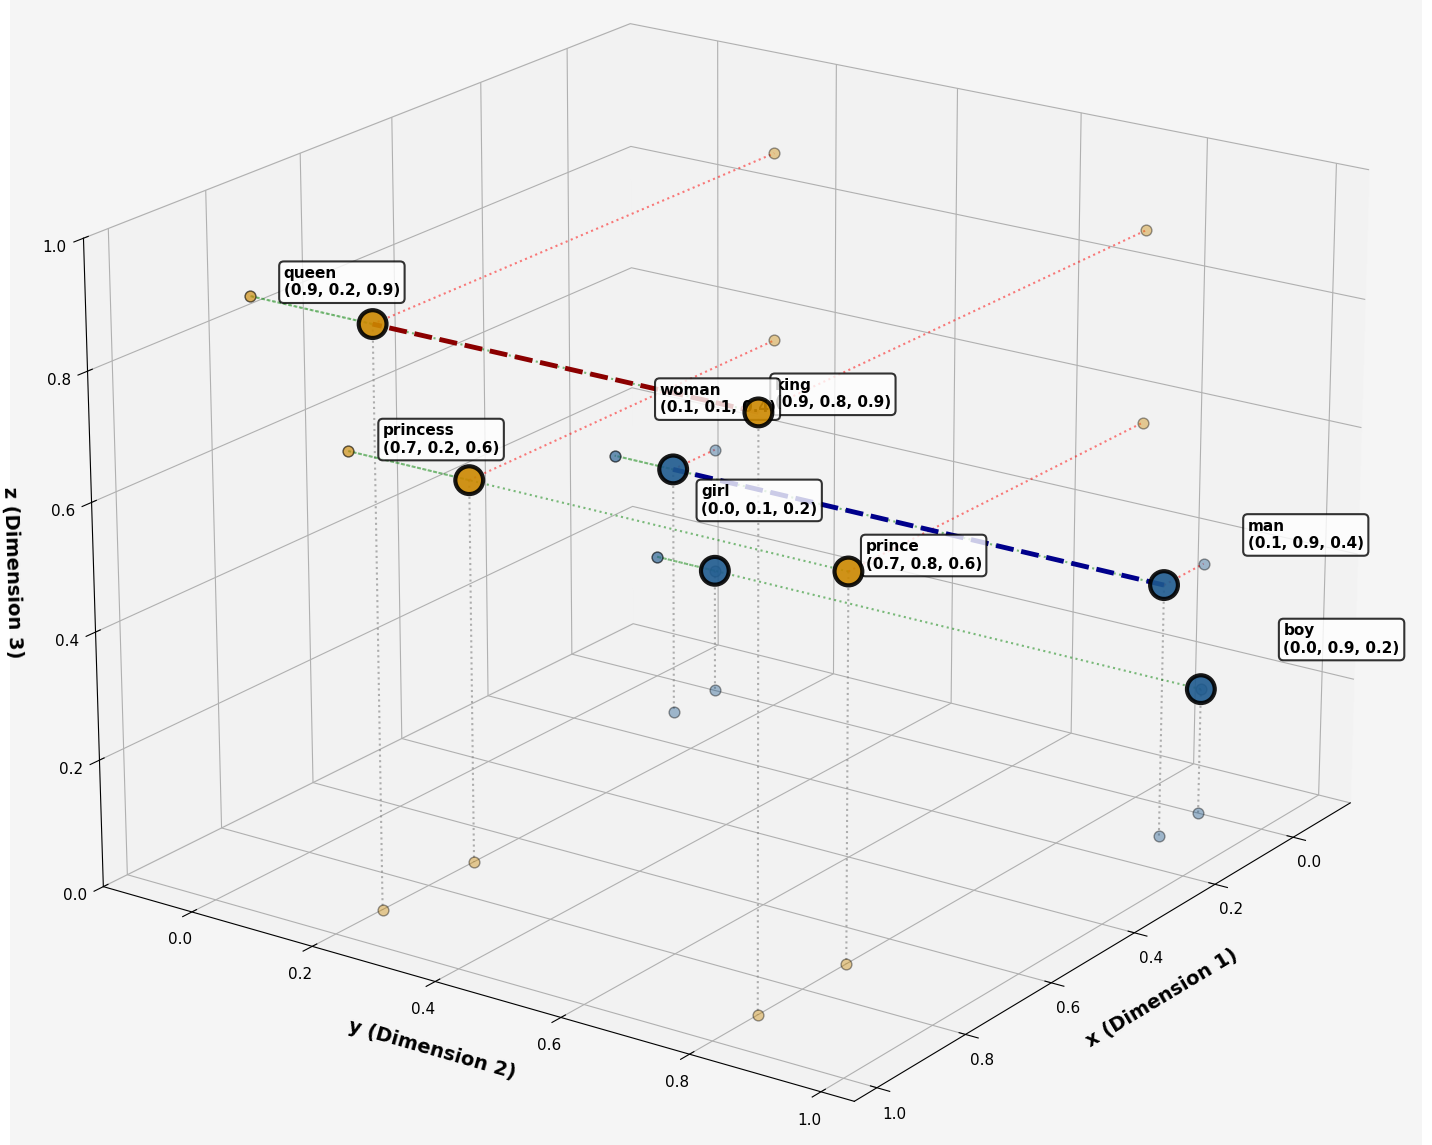

<br>

#### **Two Foundational Ideas**

**Idea 1: Meaning from distribution**

A word's meaning is defined by its surrounding words in text (the **distributional hypothesis**).

**Example:** You see these sentences:
- "Ongchoi is delicious sautéed with garlic"
- "Ongchoi is superb over rice"
- "Ongchoi leaves with salty sauces"

And you've seen:
- "Spinach sautéed with garlic over rice"
- "Chard stems and leaves are delicious"

**Conclusion:** Ongchoi is probably a leafy green like spinach, inferred purely from context.

**Idea 2: Meaning as a point in space**

Represent each word as coordinates in multidimensional space. Similar meanings are clustered in nearby points.

Early example (Osgood 1957): 3 dimensions for emotional connotation:
- **Valence:** pleasantness (love = 1.0, toxic = 0.008)
- **Arousal:** intensity (elated = 0.96, mellow = 0.07)
- **Dominance:** control (powerful = 0.99, weak = 0.05)

Modern embeddings use 100-1000 dimensions capturing far richer semantics. It can be represented in vector space in a simplified manner as shown below:

<br>

#### **Vector Semantics Definition**

Each word = vector in multidimensional space, positioned by its distribution in text.

**Key properties:**
- Similar words have similar vectors (nearby in space)
- Built automatically from text by observing word co-occurrences
- Distance between vectors = semantic similarity

**Terminology:**
- **Embedding:** Vector representation "embedded" into geometric space
- **Distributed representation:** Meaning spread across dimensions, not a single symbol
- **Distributional semantics:** Meaning derived from text distribution

Every modern NLP algorithm uses embeddings.

<br>

### **Why Vectors Over Words?**

**Word features:**
- "Previous word was 'terrible'" → requires exact match
- Fails on synonyms not in training data

**Vector features:**
- "Previous word was `[35, 22, 17]`"
- Test sees "awful" = `[34, 21, 14]` → vectors close → **generalizes to unseen words**

This enables handling synonyms, related terms, and rare words never seen in training.

<br>

### **Two Types of Embeddings**

**Count-based** (tf-idf, PMI, SVD/LSA)
- Count nearby words
- **Sparse vectors:** most dimensions zero
- Information retrieval workhorse
- SVD/LSA compresses to dense

**Neural-based** (Word2Vec, GloVE, ELMo, BERT)
- **Dense vectors:** all dimensions populated
- Train classifier to predict context
- More powerful
- Contextual variants handle polysemy

<br>

### **Sparse vs. Dense**

**Sparse:**
- `[0, 0, 0, 3, 0, 0, 1, 0, ...]` (length 50,000)
- Interpretable dimensions (each = specific word)

**Dense:**
- `[0.42, -0.15, 0.89, 0.31, -0.62, ...]` (length 300)
- Abstract dimensions (no direct word mapping)
- Better semantic relationships

---

### **Count-Based Distributed Representation**

#### **Representing Text as Vectors**

**Goal:** Convert words and documents into numerical vectors so we can compute with them.

The simplest idea is a **one-hot vector** given a vocabulary of size $V$, represent each word as a vector of length $V$ with a single `1` at that word's index and `0` everywhere else.

**Example — the word "minister":**

| a | … | left | … | office | … | minister | … | the | … | zyzzyva |
|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 0 | 0 | 0 | 0 | 0 | **1** | 0 | 0 | … | 0 |

#### **Problems with one-hot vectors**
- **High-dimensional and sparse**: the vector is as long as the entire vocabulary
- **No similarity information**: "dog" and "puppy" are equally distant from each other as "dog" and "refrigerator", because every pair of one-hot vectors is orthogonal

<br>

#### **Word-Document Matrix**

A better approach: build a **term-document matrix** $M$ where each cell records how often a word appears in a document:

$$M(i, j) = \text{count}(t_i, d_j)$$

This is a $V \times N$ matrix (vocabulary size × number of documents). Each column is a document's representation; each row is a word's representation across all documents.

This kind of document representation was central to early **information retrieval** systems, matching text queries against a database to find relevant answers.

<br>

#### **Measuring Similarity using Cosine Similarity**

Once words/documents live in vector space, we need a way to measure how similar two vectors are. The standard choice is **cosine similarity**:

$$\cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \times \|\mathbf{B}\|}$$

Where:
- $\mathbf{A} \cdot \mathbf{B}$ = dot product of the two vectors
- $\|\mathbf{A}\|, \|\mathbf{B}\|$ = magnitudes (lengths) of each vector

This gives a value between $-1$ (opposite) and $+1$ (identical direction). It measures the **angle** between vectors, ignoring their magnitude — so a short vector pointing the same way as a long one still gets a high similarity score.

<br>

#### **The Problem with Raw Frequency**

Co-occurrence matrices based on raw word counts have a flaw:

- Frequency is useful if "sugar" appears often near "apricot", that tells us something meaningful
- But extremely common words like "the", "it", "they" appear near *everything* and carry almost no useful information about context

This creates a tension: frequency matters, but the most frequent words are the least informative. Two weighting schemes address this: **TF-IDF** and **PMI**.

<br>

#### **TF-IDF (Term Frequency – Inverse Document Frequency)**

TF-IDF is a statistic that captures how important a word is within a specific document, relative to the entire collection. Given a collection $D$ of $N$ documents:

#### **Term Frequency (TF)**

$$\text{tf}(t, d) = \log_{10}(\text{count}(t, d) + 1)$$

Raw count of word $t$ in document $d$, smoothed and log-scaled to prevent large counts from dominating.

#### **Inverse Document Frequency (IDF)**

$$\text{idf}(t) = \log_{10} \frac{N}{|\{d \in D : t \in d\}|}$$

$N$ = total number of documents; the denominator counts how many documents contain word $t$. Words appearing in almost every document (e.g. stop words like "the") get a very low IDF.

#### **Combining them**

$$\text{tf-idf}(t, d, D) = \text{tf}(t, d) \times \text{idf}(t, D)$$

**Effect:** A word that is frequent in *this* document but rare across *all* documents gets a high TF-IDF score. Common words that appear everywhere get downweighted toward zero.

**Example — converting a raw counts vector to TF-IDF:**

| | left | office | minister | the |
|---|---|---|---|---|
| Counts | 9 | 21 | 17 | 63 |
| TF-IDF | 0.14 | 0.3 | 0.47 | **0** |

Notice "the" drops to 0 because it appears in every document (IDF ≈ 0).

<br>

#### **Pointwise Mutual Information (PMI)**

PMI asks: **do two words co-occur more than we'd expect by chance?**

$$\text{PMI}(w_1, w_2) = \log_2 \frac{P(w_1, w_2)}{P(w_1) \cdot P(w_2)}$$

Where:
- $P(w_1, w_2)$ = probability of seeing both words together (joint probability)
- $P(w_1), P(w_2)$ = individual probabilities of each word (marginals)

**Interpretation:**
- PMI > 0 → the words co-occur **more** than chance would predict
- PMI = 0 → the words co-occur exactly as often as expected
- PMI < 0 → the words co-occur **less** than expected

<br>

#### **Positive PMI (PPMI)**

PMI ranges from $-\infty$ to $+\infty$, but negative values are problematic (unreliable for rare events). The fix is simple — clamp negatives to zero:

$$\text{PPMI}(w_1, w_2) = \max\left(\log_2 \frac{P(w_1, w_2)}{P(w_1) \cdot P(w_2)},\ 0\right)$$

<br>

#### **Computing PPMI (Worked Example)**

Start with a **term-context co-occurrence matrix** $F$ with $W$ rows (words) and $C$ columns (context words). Each cell $f_{ij}$ is how often word $w_i$ appears in context $c_j$.

#### **Step 1 — Raw counts**

| | computer | data | result | pie | sugar | count(w) |
|---|---|---|---|---|---|---|
| cherry | 2 | 8 | 9 | 442 | 25 | 486 |
| strawberry | 0 | 0 | 1 | 60 | 19 | 80 |
| digital | 1670 | 1683 | 85 | 5 | 4 | 3447 |
| information | 3325 | 3982 | 378 | 5 | 13 | 7703 |
| **count(context)** | 4997 | 5673 | 473 | 512 | 61 | **11716** |

#### **Step 2 — Convert to probabilities**

$$p_{ij} = \frac{f_{ij}}{\sum\sum f_{ij}}, \quad p(w_i) = \frac{\text{count}(w_i)}{N}, \quad p(c_j) = \frac{\text{count}(c_j)}{N}$$

where $N = 11716$ (total of all counts).

**Example:** $P(w{=}\text{information}, c{=}\text{data}) = 3982 / 11716 = 0.3399$

#### **Step 3 — Compute PMI, then clamp to get PPMI**

$\text{PMI}(\text{information}, \text{data}) = \log_2\left(\frac{0.3399}{0.6575 \times 0.4842}\right) = 0.0944$

#### **Resulting PPMI matrix**

| | computer | data | result | pie | sugar |
|---|---|---|---|---|---|
| cherry | 0 | 0 | 0 | 4.38 | 3.30 |
| strawberry | 0 | 0 | 0 | 4.10 | 5.51 |
| digital | 0.18 | 0.01 | 0 | 0 | 0 |
| information | 0.02 | 0.09 | 0.28 | 0 | 0 |

Now "cherry" and "strawberry" are close to each other (both have high values for "pie" and "sugar"), while "digital" and "information" cluster together (high values for "computer" and "data"). The vectors capture **semantic similarity**.

---